In [1]:
!pip install boto3 scikit-learn pandas numpy matplotlib pyarrow

  Using cached boto3-1.43.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached botocore-1.43.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached jmespath-1.1.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached s3transfer-0.17.0-py3-none-any.whl.metadata (1.7 kB)
Using cached boto3-1.43.0-py3-none-any.whl (140 kB)
Using cached botocore-1.43.0-py3-none-any.whl (15.0 MB)
Using cached jmespath-1.1.0-py3-none-any.whl (20 kB)
Using cached s3transfer-0.17.0-py3-none-any.whl (86 kB)


In [2]:
!pip install psycopg2-binary sqlalchemy

production: 150 записей
well_targets: 90 записей
Объединённых записей: 90

Linear Regression - MAE: 0.86, RMSE: 1.19
Random Forest - MAE: 0.27, RMSE: 0.38

Важность признаков (Random Forest)
          feature  importance
2      energy_kwh    0.465320
1     temperature    0.437913
0        pressure    0.095974
3  downtime_hours    0.000793


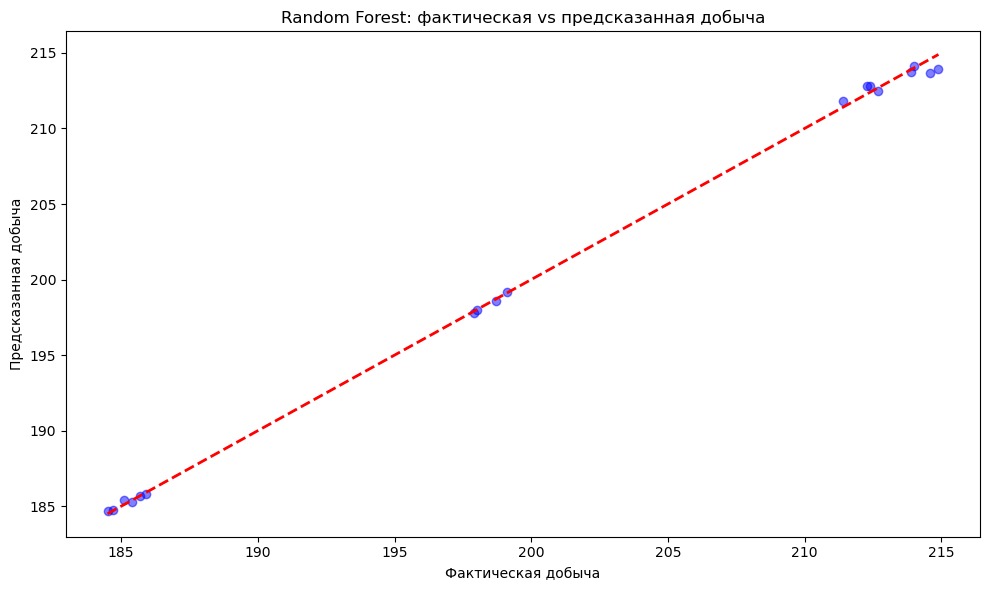

In [6]:
import pandas as pd
import numpy as np
import boto3
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import psycopg2

s3_client = boto3.client(
    's3',
    endpoint_url='http://minio:9000',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin',
    region_name='us-east-1'
)

bucket_name = 'oil-data'

def read_parquet_from_minio(key):
    obj = s3_client.get_object(Bucket=bucket_name, Key=key)
    return pd.read_parquet(BytesIO(obj['Body'].read()))

production = read_parquet_from_minio('raw/production/data.parquet')
well_targets = read_parquet_from_minio('raw/well_targets/data.parquet')

print(f"production: {len(production)} записей")
print(f"well_targets: {len(well_targets)} записей")

production['date'] = pd.to_datetime(production['date']).dt.date
well_targets['date'] = pd.to_datetime(well_targets['date']).dt.date

merged = production.merge(well_targets, on=['well_id', 'date'], how='inner')
print(f"Объединённых записей: {len(merged)}")

features = ['pressure', 'temperature', 'energy_kwh', 'downtime_hours']
X = merged[features]
y = merged['daily_oil_ton']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"\nLinear Regression - MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")

importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nВажность признаков (Random Forest)")
print(importance)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Фактическая добыча')
plt.ylabel('Предсказанная добыча')
plt.title('Random Forest: фактическая vs предсказанная добыча')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

conn = psycopg2.connect(
    host="postgres",
    port=5432,
    database="oil_gas",
    user="oil",
    password="oil123"
)

test_indices = y_test.index
results = merged.iloc[test_indices][['date', 'daily_oil_ton']].copy()
results['predicted'] = y_pred_rf
results.rename(columns={'daily_oil_ton': 'actual'}, inplace=True)

conn = psycopg2.connect(
    host="postgres",
    port=5432,
    database="oil_gas",
    user="oil",
    password="oil123"
)

cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS predictions")

cursor.execute("""
    CREATE TABLE predictions (
        date DATE,
        actual FLOAT,
        predicted FLOAT
    )
""")

for i in range(len(results)):
    cursor.execute("""
        INSERT INTO predictions (date, actual, predicted)
        VALUES (%s, %s, %s)
    """, (
        results.iloc[i]['date'],
        float(results.iloc[i]['actual']),
        float(results.iloc[i]['predicted'])
    ))

conn.commit()
conn.close()